# **Netflix Movie Rating Analysis**
`This project explores the trends and patterns in Netflix movie ratings using Python, Matplotlib, and Seaborn. The analysis focuses on key aspects such as the most frequent genres, highest-voted genres, the most and least popular movies, and the year with the most filmed movies. The dataset will be preprocessed to ensure accurate insights, including converting date columns, splitting genre data, and categorizing vote averages into meaningful bins. Through visualizations, this project will provide a clear representation of movie trends and popularity on Netflix.`

In [2]:
#Importing Dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Getting the Data

In [4]:
df = pd.read_csv("./Data-Files/netflixmovie.csv",lineterminator="\n")

In [5]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


### Cleaning and Preprocessing the data

In [7]:
# Checking for duplicates 
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [8]:
# Checking for null values 

df.isna().sum()
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [10]:
#Casting the Release date column as date from  object 

df.Release_Date = pd.to_datetime(df.Release_Date)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   int64         
 5   Vote_Average       9827 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9827 non-null   object        
 8   Poster_Url         9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 691.1+ KB


In [12]:
# Storing only the Year from Release Date in a new Column

df["Release_Year"] = df.Release_Date.dt.year


In [13]:
# Dropping columns that are of no use for our analysis 

df.drop(['Release_Date','Overview','Original_Language','Poster_Url'],axis=1,inplace=True)

In [14]:
df

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,6.3,Thriller,2022
3,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021
...,...,...,...,...,...,...
9822,Badlands,13.357,896,7.6,"Drama, Crime",1973
9823,Violent Delights,13.356,8,3.5,Horror,2020
9824,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror",2016
9825,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",2021


In [15]:
#Creating bins for Vote_average Columns for analysis

label_list = ['Not Popular','Below Average','Average','Popular']

def Categorize_votes(df, columns, label):
    edges = [
        df[columns].describe()['min'],
        df[columns].describe()['25%'],
        df[columns].describe()['50%'],
        df[columns].describe()['75%'],
        df[columns].describe()['max']
    ]

    df[columns] = pd.cut(df[columns],edges,labels=label,duplicates='drop')

    return df

In [16]:
Categorize_votes(df,'Vote_Average',label=label_list)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,Below Average,Thriller,2022
3,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War",2021
...,...,...,...,...,...,...
9822,Badlands,13.357,896,Popular,"Drama, Crime",1973
9823,Violent Delights,13.356,8,Not Popular,Horror,2020
9824,The Offering,13.355,94,Not Popular,"Mystery, Thriller, Horror",2016
9825,The United States vs. Billie Holiday,13.354,152,Average,"Music, Drama, History",2021


In [17]:
# Splitting the Genre Columns using Split method and converting genre as a category dtype

df.Genre = df.Genre.str.split(', ')
df = df.explode('Genre').reset_index(drop = True)

In [18]:
df.Genre = df.Genre.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Title         25793 non-null  object  
 1   Popularity    25793 non-null  float64 
 2   Vote_Count    25793 non-null  int64   
 3   Vote_Average  25552 non-null  category
 4   Genre         25793 non-null  category
 5   Release_Year  25793 non-null  int32   
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.7+ KB


In [19]:
df.Genre.dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [20]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

### Data Visualization 

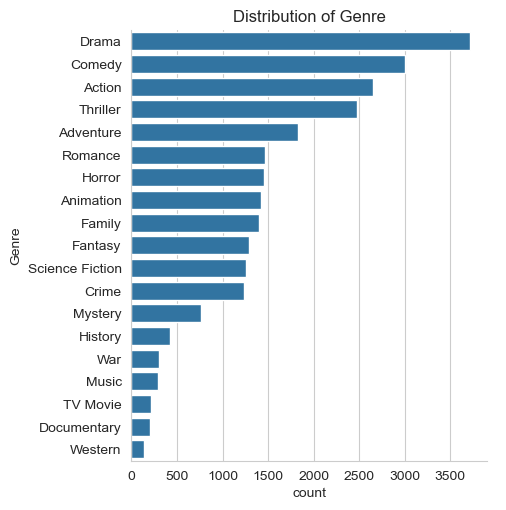

In [22]:
#Creating Visualization For Distribution of Genre
sns.set_style('whitegrid')
sns.catplot(data=df,y = "Genre",kind='count',order=df.Genre.value_counts().index)
plt.title('Distribution of Genre')
plt.show()

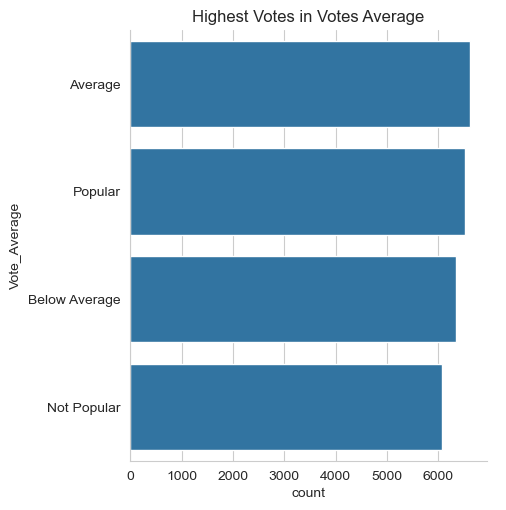

In [68]:
#Visualization for Distribution of Highest vote type in vote category

sns.catplot(y='Vote_Average',data=df,kind='count',order=df.Vote_Average.value_counts().index)
plt.title("Highest Votes in Votes Average")
plt.show()

In [24]:
#Data mining to get the most popular movie

df[df.Popularity== df.Popularity.max()].head(1)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021


In [25]:
#Data mining to get the least popular movie

df[df.Popularity==df.Popularity.min()].head(1)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
25787,The United States vs. Billie Holiday,13.354,152,Average,Music,2021


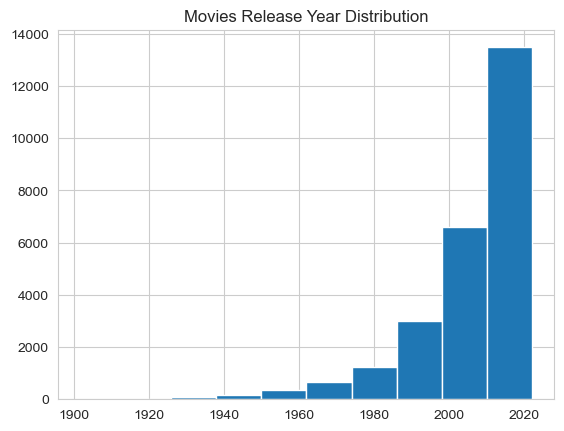

In [65]:
#Visualization for the distribution of years and the movies released in those years

df.Release_Year.hist()
plt.title('Movies Release Year Distribution')
plt.show(
)

## Summary

    The analysis revealed that `Drama` genres are more frequently released on Netflix.
    `The most and least popular movies were Spider Man No Way Home and The United States vs. Billie Holiday` respectively , along 
      with their respective genres.
      
    Additionally, the year with the highest number of movie releases was 2020. 
    
    To achieve these insights, extensive data preprocessing was performed, including formatting dates, splitting genre data, and categorizing vote averages into different levels of popularity. 

### Netflix Movie Rating Analysis
## Data Collection & Understanding

`The dataset was sourced from Netflix, containing information about movie genres, ratings, votes, and release years.
An initial exploration of the dataset was performed to understand its structure, missing values, and inconsistencies.
`

**Data Preprocessing**

    Date Conversion: The date column was converted from an object type to a datetime format for accurate time-based analysis.
    Genre Splitting: Since some movies belonged to multiple genres, the genre column was split to analyze each genre separately.
    Vote Binning: The vote average column was categorized into four bins—No Popularity, Below Average, Average, and Popular—to 
    better interpret rating trends.
    
**Exploratory Data Analysis (EDA)**

    Genre Analysis: The most frequently occurring genre was identified.
    Vote-Based Genre Ranking: Genres with the highest average votes were determined.
    Popularity Evaluation: The most and least popular movies were identified, along with their respective genres.
    Yearly Trend Analysis: The year with the highest number of movie releases was analyzed.
    
**Data Visualization**
    
    Matplotlib and Seaborn were used to create visual representations, such as bar charts and histograms, to highlight trends and 
    insights.
    Each visualization was designed to enhance interpretability and support the findings.
    
**Conclusion & Insights**
    
    The results were interpreted based on the analysis, providing valuable insights into Netflix movie trends.
    The findings were summarized to conclude the project, highlighting key patterns observed in the dataset.